In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
# Set the random seed for reproducibility
np.random.seed(42)

In [ ]:
# Create sample dataset with outliers
df = pd.DataFrame({
    'height': np.concatenate([
        np.random.normal(175, 7, 95),  # Normal heights in cm
        np.array([150, 155, 200, 205, 210])  # Outliers
    ]),
    'weight': np.concatenate([
        np.random.normal(70, 10, 95),  # Normal weights in kg
        np.array([40, 45, 120, 125, 130])  # Outliers
    ]),
    'salary': np.concatenate([
        np.random.lognormal(10.5, 0.4, 95),  # Normal salaries
        np.array([500000, 520000, 550000, 600000, 1000000])  # Outliers
    ])
})

In [ ]:
# Display dataset head and basic statistics
df.head()

,height,weight,salary
0,178.476999,55.364851,30375.572226
1,174.032150,72.961203,51152.135370
2,179.533820,72.610553,39562.520524
3,185.661209,70.051135,22064.041668
4,173.360926,67.654129,38920.343822


In [ ]:
# Quick data summary
df.describe()


,height,weight,salary
count,100.000000,100.000000,100.000000
mean,174.802581,71.397280,70575.816571
std,8.824677,13.932214,138019.017873
min,150.000000,40.000000,9931.760814
25%,170.712081,61.943395,27742.715939
50%,174.111306,70.841072,38441.915870
75%,178.918874,76.333889,51091.331090
max,210.000000,130.000000,1000000.000000


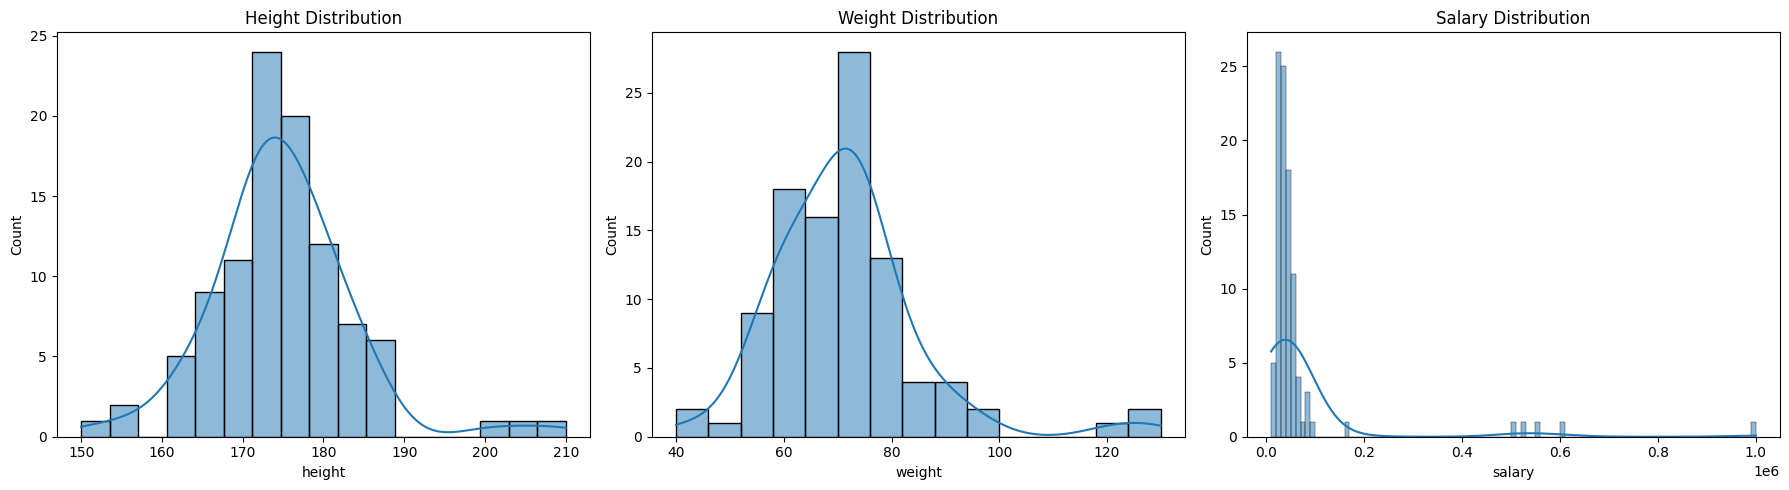

In [ ]:
# Visualize distributions to identify potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['height'], kde=True)
plt.title('Height Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['weight'], kde=True)
plt.title('Weight Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['salary'], kde=True)
plt.title('Salary Distribution')

plt.tight_layout()
plt.show()

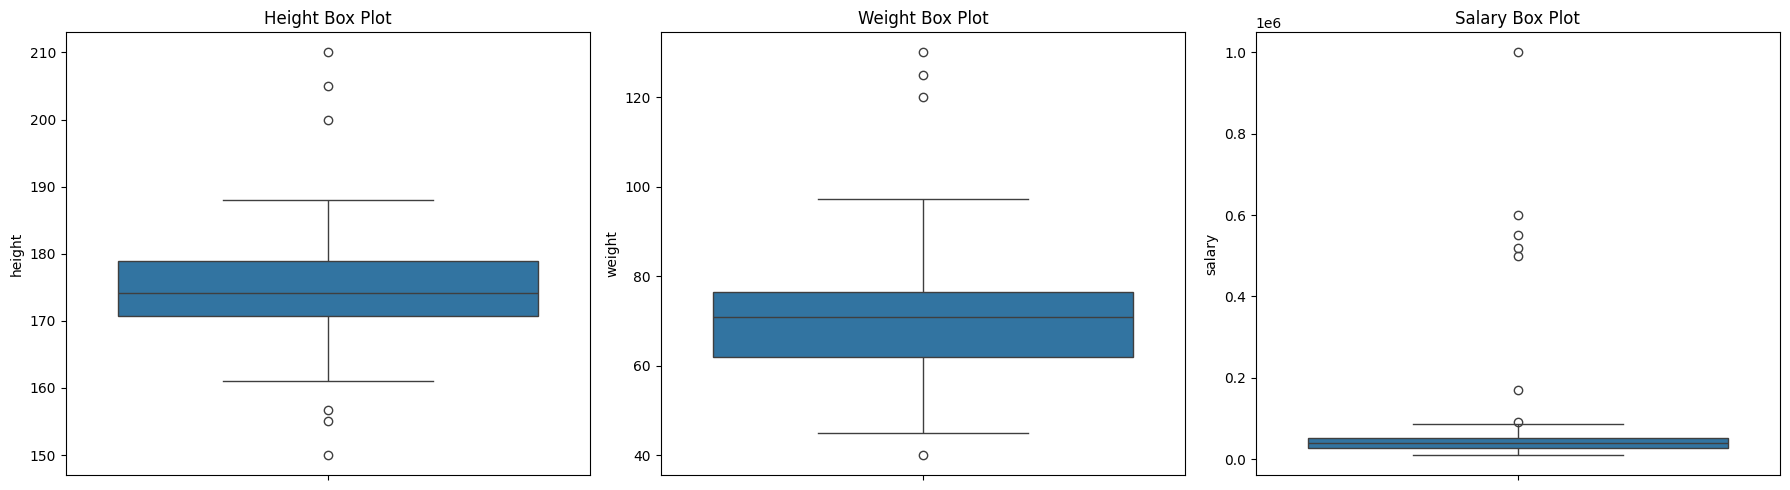

In [ ]:
# Box plots to visualize potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['weight'])
plt.title('Weight Box Plot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['salary'])
plt.title('Salary Box Plot')

plt.tight_layout()
plt.show()

In [ ]:
# Scatter plots to identify patterns and potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='height', y='weight', data=df)
plt.title('Height vs Weight')

plt.subplot(1, 3, 2)
sns.scatterplot(x='height', y='salary', data=df)
plt.title('Height vs Salary')

plt.subplot(1, 3, 3)
sns.scatterplot(x='weight', y='salary', data=df)
plt.title('Weight vs Salary')

plt.tight_layout()
plt.show()

In [ ]:
# Define function for Z-score outlier detection
def detect_outliers_zscore(data, threshold=3):
    """
    Detect outliers using Z-score method
    Returns indices of outliers
    """
    z_scores = np.abs(stats.zscore(data))
    return np.where(z_scores > threshold)[0]


In [ ]:
# Apply Z-score outlier detection
height_outliers_z = detect_outliers_zscore(df['height'])
weight_outliers_z = detect_outliers_zscore(df['weight'])
salary_outliers_z = detect_outliers_zscore(df['salary'])

print(f"Height outliers (Z-score): {len(height_outliers_z)} found at indices {height_outliers_z}")
print(f"Weight outliers (Z-score): {len(weight_outliers_z)} found at indices {weight_outliers_z}")
print(f"Salary outliers (Z-score): {len(salary_outliers_z)} found at indices {salary_outliers_z}")


Height outliers (Z-score): 2 found at indices [98 99]
Weight outliers (Z-score): 3 found at indices [97 98 99]
Salary outliers (Z-score): 5 found at indices [95 96 97 98 99]


In [ ]:
# Define function for IQR outlier detection
def detect_outliers_iqr(data, factor=1.5):
    """
    Detect outliers using IQR method
    Returns indices of outliers
    """
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return np.where((data < lower_bound) | (data > upper_bound))[0]


In [ ]:
# Apply IQR outlier detection
height_outliers_iqr = detect_outliers_iqr(df['height'])
weight_outliers_iqr = detect_outliers_iqr(df['weight'])
salary_outliers_iqr = detect_outliers_iqr(df['salary'])

print(f"Height outliers (IQR): {len(height_outliers_iqr)} found at indices {height_outliers_iqr}")
print(f"Weight outliers (IQR): {len(weight_outliers_iqr)} found at indices {weight_outliers_iqr}")
print(f"Salary outliers (IQR): {len(salary_outliers_iqr)} found at indices {salary_outliers_iqr}")


Height outliers (IQR): 6 found at indices [74 95 96 97 98 99]
Weight outliers (IQR): 4 found at indices [95 97 98 99]
Salary outliers (IQR): 7 found at indices [19 30 95 96 97 98 99]


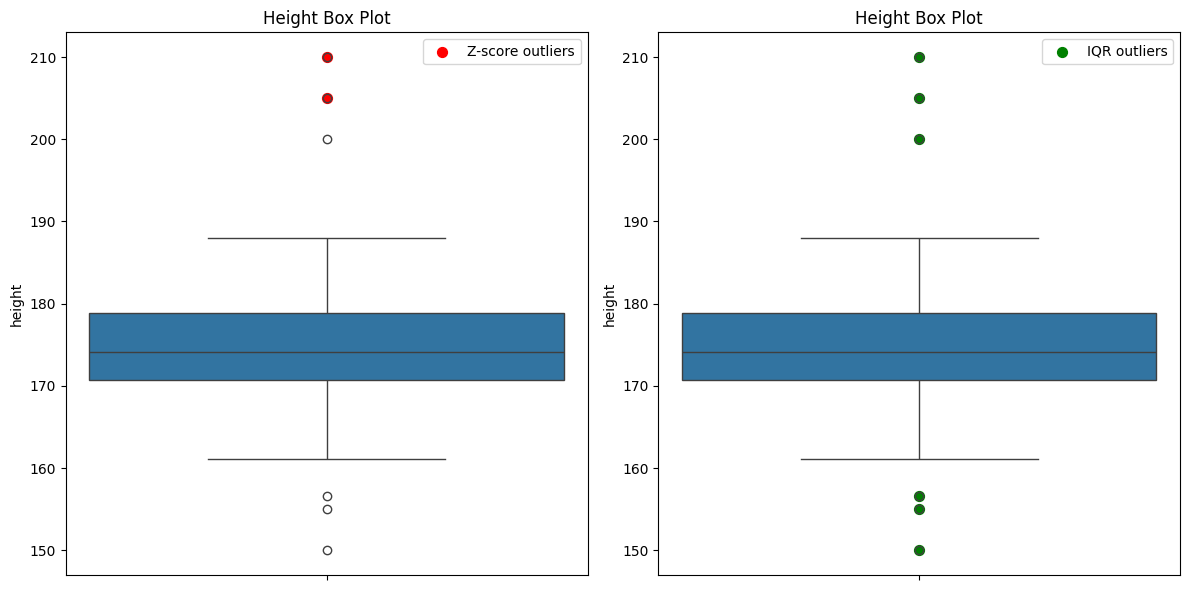

In [ ]:
# Visualize the detected outliers for height using box plot with highlighted outliers
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_z), df['height'].iloc[height_outliers_z],
            color='red', s=50, label='Z-score outliers')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_iqr), df['height'].iloc[height_outliers_iqr],
            color='green', s=50, label='IQR outliers')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Examining the impact of outliers on statistical measures
print("With outliers:")
print(f"Height mean: {df['height'].mean():.2f}, std: {df['height'].std():.2f}")
print(f"Weight mean: {df['weight'].mean():.2f}, std: {df['weight'].std():.2f}")
print(f"Salary mean: {df['salary'].mean():.2f}, std: {df['salary'].std():.2f}")


With outliers:
Height mean: 174.80, std: 8.82
Weight mean: 71.40, std: 13.93
Salary mean: 70575.82, std: 138019.02


In [ ]:
# Create copies without outliers (using IQR method)
df_no_outliers = df.copy()
all_outliers = list(set(height_outliers_iqr) | set(weight_outliers_iqr) | set(salary_outliers_iqr))
df_no_outliers = df_no_outliers.drop(all_outliers).reset_index(drop=True)

print("\nWithout outliers:")
print(f"Height mean: {df_no_outliers['height'].mean():.2f}, std: {df_no_outliers['height'].std():.2f}")
print(f"Weight mean: {df_no_outliers['weight'].mean():.2f}, std: {df_no_outliers['weight'].std():.2f}")
print(f"Salary mean: {df_no_outliers['salary'].mean():.2f}, std: {df_no_outliers['salary'].std():.2f}")



Without outliers:
Height mean: 174.65, std: 6.18
Weight mean: 70.19, std: 9.50
Salary mean: 39059.91, std: 15713.95


In [ ]:
# Handling outliers using different approaches
# 1. Removal (already done above)
# 2. Capping (Winsorization)
def winsorize(data, limits=(0.05, 0.05)):
    """Apply winsorization to limit extreme values"""
    lower_limit = np.percentile(data, limits[0] * 100)
    upper_limit = np.percentile(data, 100 - limits[1] * 100)
    return np.clip(data, lower_limit, upper_limit)

df_winsorized = df.copy()
df_winsorized['height'] = winsorize(df['height'])
df_winsorized['weight'] = winsorize(df['weight'])
df_winsorized['salary'] = winsorize(df['salary'])


In [ ]:
# 3. Log transformation (especially useful for skewed data like salary)
df_log = df.copy()
df_log['salary'] = np.log(df['salary'])


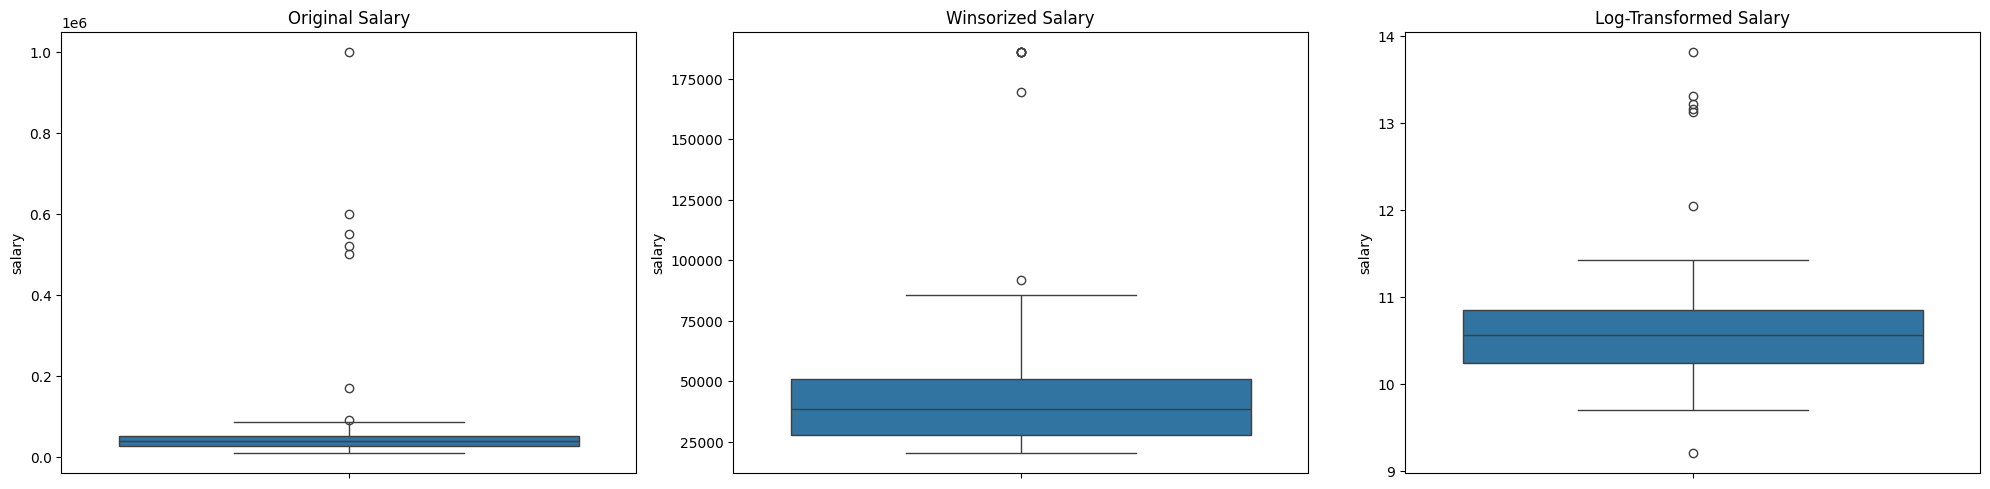

In [ ]:
# Compare the distributions before and after transformation
plt.figure(figsize=(20, 5))

# Original distributions
plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

# After winsorization
plt.subplot(1, 3, 2)
sns.boxplot(y=df_winsorized['salary'])
plt.title('Winsorized Salary')

# After log transformation
plt.subplot(1, 3, 3)
sns.boxplot(y=df_log['salary'])
plt.title('Log-Transformed Salary')

plt.tight_layout()
plt.show()

In [ ]:
# Feature associations and correlation analysis
# Calculate correlation matrix
corr_matrix = df.corr()


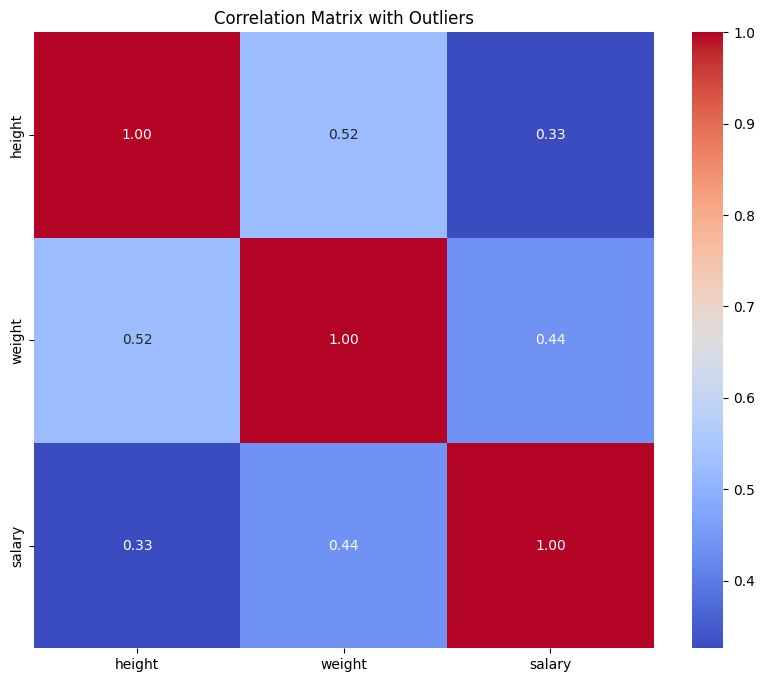

In [ ]:
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix with Outliers')
plt.show()


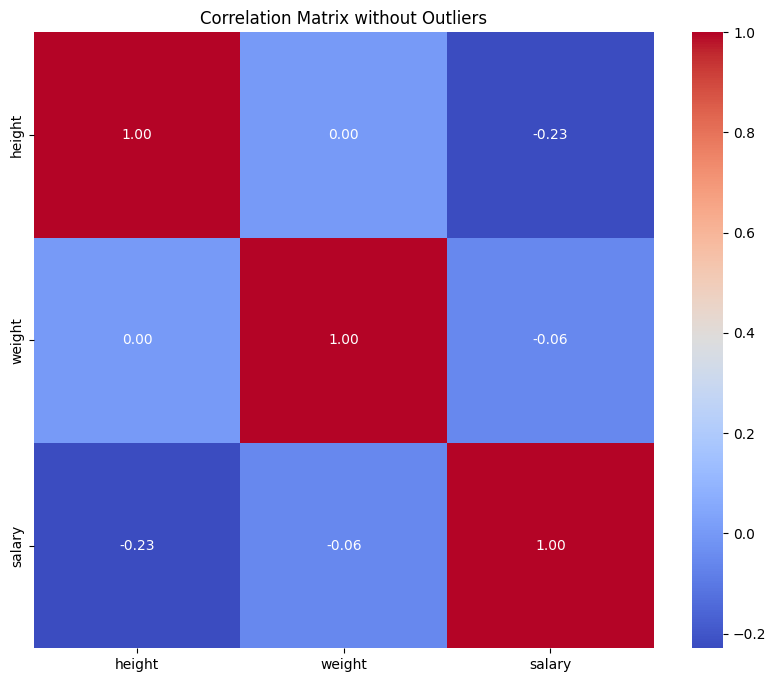

In [ ]:
# Compare with correlation after removing outliers
corr_matrix_no_outliers = df_no_outliers.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_no_outliers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix without Outliers')
plt.show()


In [ ]:
# Create function to profile features and detect potential issues
def profile_feature(data, feature_name):
    """Create a basic profile of a numeric feature"""
    feature = data[feature_name]

    # Basic statistics
    stats_dict = {
        'Count': len(feature),
        'Mean': feature.mean(),
        'Median': feature.median(),
        'Std Dev': feature.std(),
        'Min': feature.min(),
        'Max': feature.max(),
        'Range': feature.max() - feature.min(),
        'IQR': np.percentile(feature, 75) - np.percentile(feature, 25),
        'Skewness': stats.skew(feature),
        'Kurtosis': stats.kurtosis(feature),
        'Missing Values': feature.isna().sum(),
        'Missing %': feature.isna().mean() * 100
    }

    # Z-score outliers
    z_outliers = detect_outliers_zscore(feature)
    stats_dict['Z-score Outliers'] = len(z_outliers)
    stats_dict['Z-score Outlier %'] = len(z_outliers) / len(feature) * 100

    # IQR outliers
    iqr_outliers = detect_outliers_iqr(feature)
    stats_dict['IQR Outliers'] = len(iqr_outliers)
    stats_dict['IQR Outlier %'] = len(iqr_outliers) / len(feature) * 100

    return pd.Series(stats_dict, name=feature_name)


In [ ]:
# Apply feature profiling to the dataset
profile_results = pd.DataFrame([
    profile_feature(df, 'height'),
    profile_feature(df, 'weight'),
    profile_feature(df, 'salary')
])

# Display the feature profiles
profile_results


,Count,Mean,Median,Std Dev,Min,Max,Range,IQR,Skewness,Kurtosis,Missing Values,Missing %,Z-score Outliers,Z-score Outlier %,IQR Outliers,IQR Outlier %
height,100.0,174.802581,174.111306,8.824677,150.000000,210.0,60.000000,8.206793,0.802248,3.330725,0.0,0.0,2.0,2.0,6.0,6.0
weight,100.0,71.397280,70.841072,13.932214,40.000000,130.0,90.000000,14.390494,1.587588,4.962706,0.0,0.0,3.0,3.0,4.0,4.0
salary,100.0,70575.816571,38441.915870,138019.017873,9931.760814,1000000.0,990068.239186,23348.615150,4.740303,23.787349,0.0,0.0,5.0,5.0,7.0,7.0


In [ ]:
# Fixed function for multivariate outlier detection
def detect_multivariate_outliers(data, method='mahalanobis', threshold=0.99):
    """
    Detect multivariate outliers using Mahalanobis distance
    Returns indices of outliers
    """
    if method == 'mahalanobis':
        # Calculate Mahalanobis distance
        x = data.values
        covariance_matrix = np.cov(x, rowvar=False)
        inv_covariance_matrix = np.linalg.inv(covariance_matrix)
        mean_vector = np.mean(x, axis=0)

        # Implement mahalanobis distance manually
        mahalanobis_dist = []
        for i in range(x.shape[0]):
            x_i = x[i, :]
            # Calculate mahalanobis distance: (x-μ)ᵀΣ⁻¹(x-μ)
            diff = x_i - mean_vector
            mahal = np.sqrt(diff.dot(inv_covariance_matrix).dot(diff.T))
            mahalanobis_dist.append(mahal)

        # Convert to array
        mahalanobis_dist = np.array(mahalanobis_dist)

        # Find threshold using chi-squared distribution
        threshold_value = stats.chi2.ppf(threshold, df=x.shape[1])

        # Return indices of outliers
        return np.where(mahalanobis_dist > threshold_value)[0]
    else:
        raise ValueError("Only 'mahalanobis' method is currently supported")


In [ ]:
# Apply multivariate outlier detection
multivariate_outliers = detect_multivariate_outliers(df, threshold=0.95)
print(f"Multivariate outliers: {len(multivariate_outliers)} found at indices {multivariate_outliers}")


Multivariate outliers: 0 found at indices []


<Figure size 1200x1000 with 0 Axes>

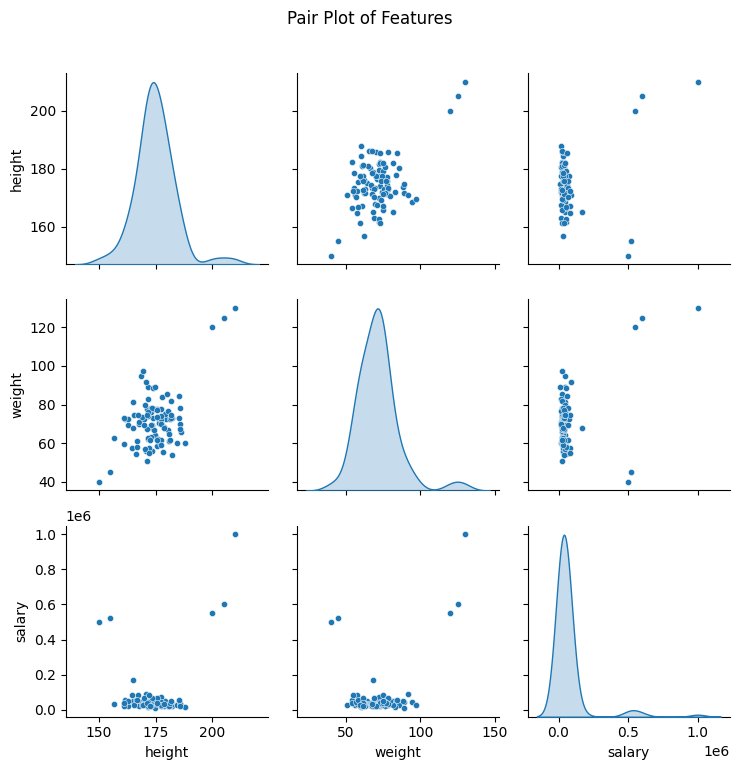

In [ ]:
# Visualize the multivariate outliers in a pair plot
plt.figure(figsize=(12, 10))
sns.pairplot(df, diag_kind='kde', plot_kws={"s": 20})
plt.suptitle('Pair Plot of Features', y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1043/3117540217.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


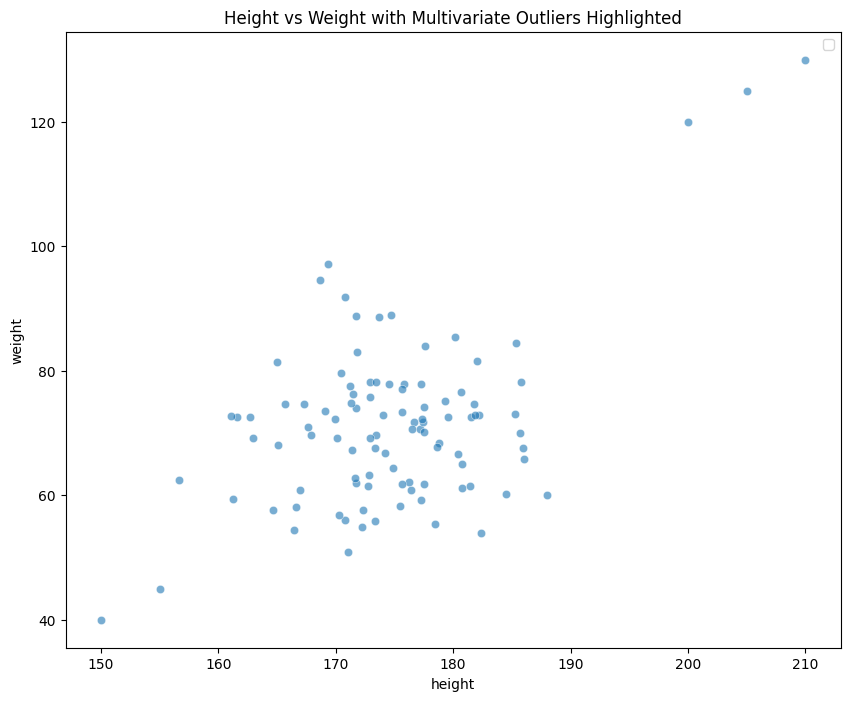

In [ ]:
# Highlight the multivariate outliers in a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='height', y='weight', data=df, alpha=0.6)
sns.scatterplot(x='height', y='weight', data=df.iloc[multivariate_outliers],
                color='red', s=100, label='Multivariate Outliers')
plt.title('Height vs Weight with Multivariate Outliers Highlighted')
plt.legend()
plt.show()


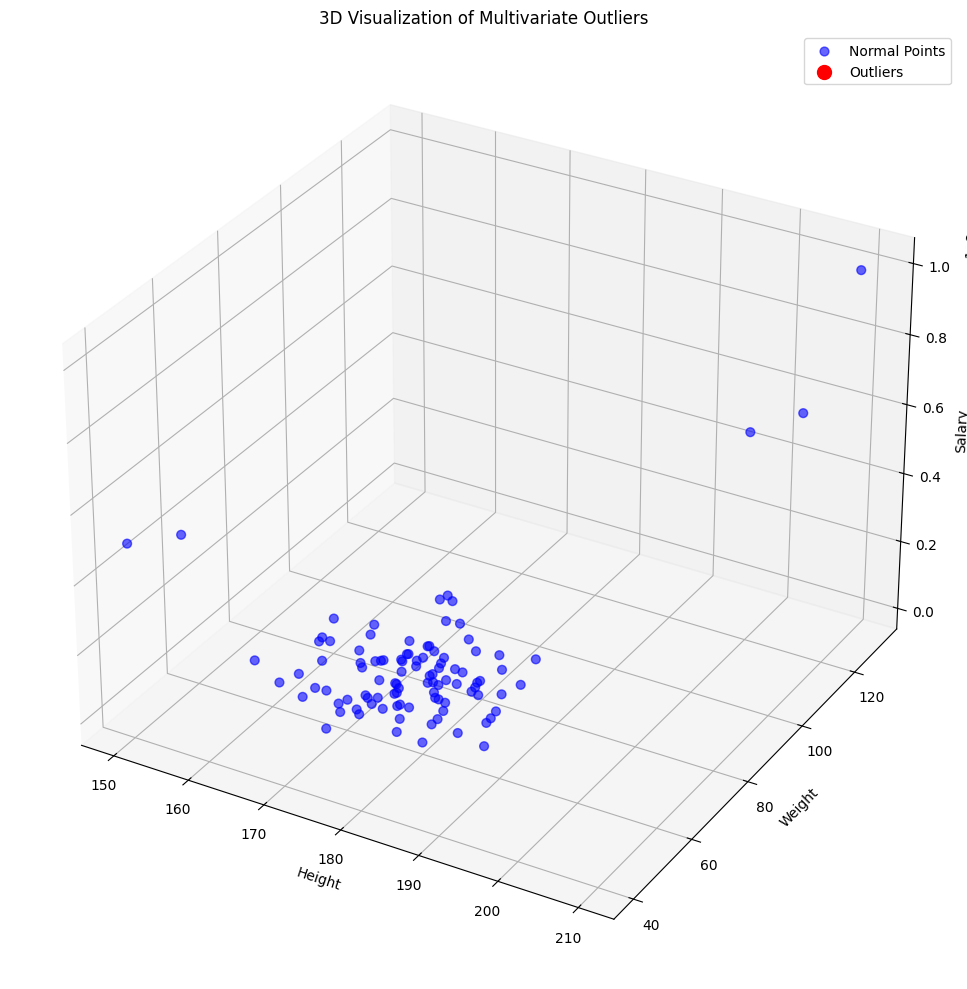

In [ ]:
# 3D visualization of outliers
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Regular points
ax.scatter(df['height'], df['weight'], df['salary'], c='blue', s=40, alpha=0.6, label='Normal Points')
# Outliers
ax.scatter(df.iloc[multivariate_outliers]['height'], df.iloc[multivariate_outliers]['weight'],
           df.iloc[multivariate_outliers]['salary'], c='red', s=100, label='Outliers')

ax.set_xlabel('Height')
ax.set_ylabel('Weight')
ax.set_zlabel('Salary')
ax.set_title('3D Visualization of Multivariate Outliers')
plt.legend()
plt.tight_layout()
plt.show()


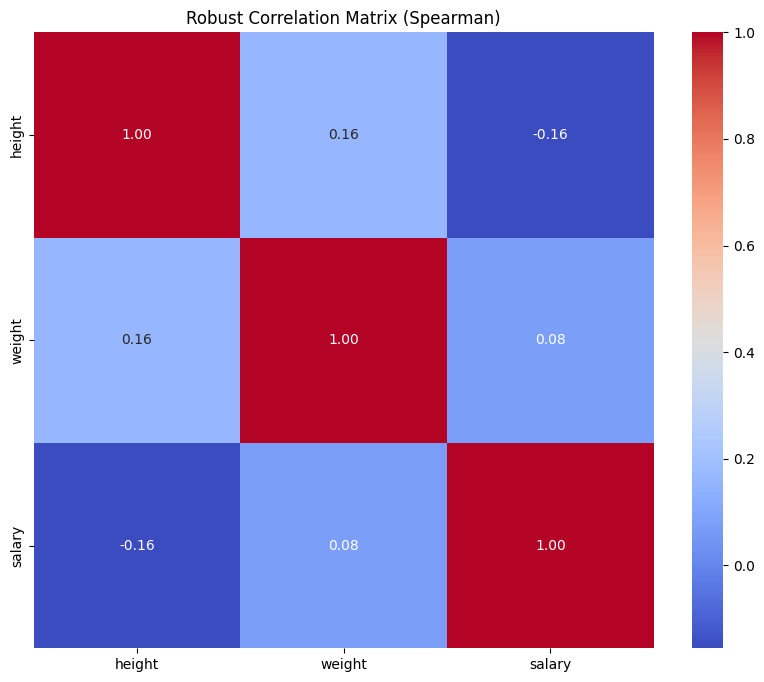

In [ ]:
# Simple robust correlation calculation using Spearman instead of Pearson
robust_corr = df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(robust_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Robust Correlation Matrix (Spearman)')
plt.show()


In [ ]:
# Apply different scaling methods before and after outlier treatment
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [ ]:
# Original data
scaler_standard = StandardScaler()
df_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(df),
    columns=df.columns
)


In [ ]:
# Using robust scaler which is less influenced by outliers
scaler_robust = RobustScaler()
df_scaled_robust = pd.DataFrame(
    scaler_robust.fit_transform(df),
    columns=df.columns
)

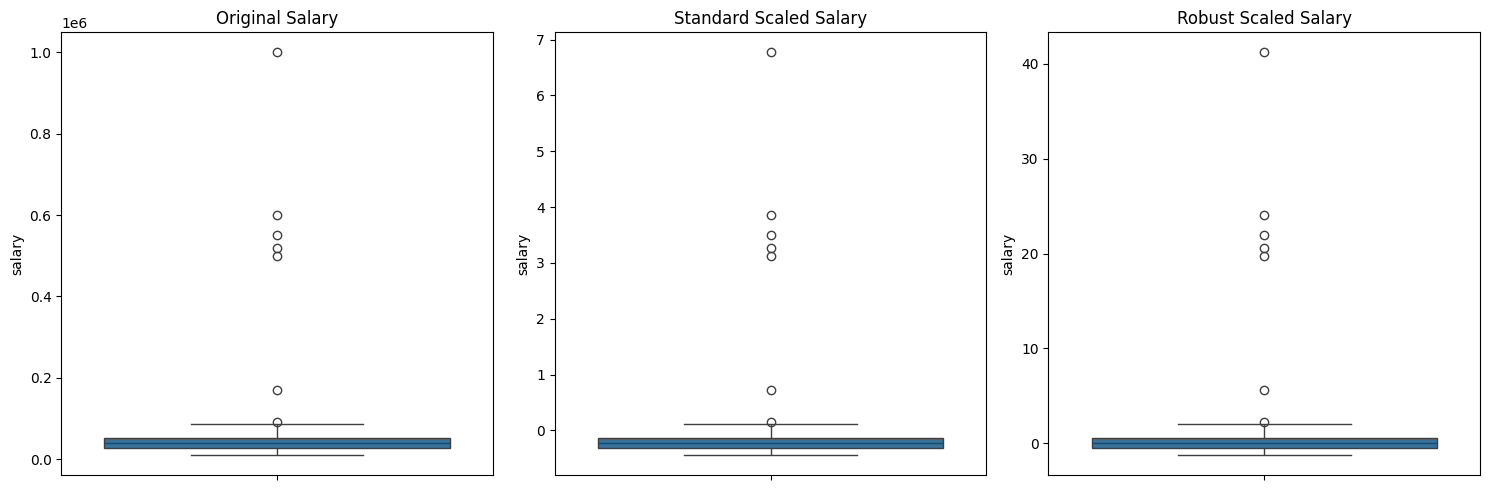

In [ ]:
# Compare the scaled distributions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_scaled_standard['salary'])
plt.title('Standard Scaled Salary')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_scaled_robust['salary'])
plt.title('Robust Scaled Salary')

plt.tight_layout()
plt.show()


In [ ]:
# Demonstrate impact of outliers on linear regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [ ]:
# Create dataset with outlier
x = np.array(range(20)).reshape(-1, 1)
y = 2*x.ravel() + 5 + np.random.normal(0, 1, 20)
y[19] = 80  # add outlier

plt.figure(figsize=(12, 6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'With Outlier: y = 2.57x + 1.40')

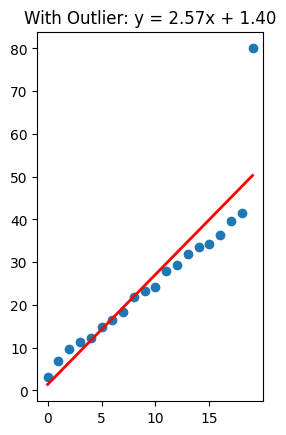

In [ ]:
# Plot with outlier
plt.subplot(1, 2, 1)
plt.scatter(x, y)
model = LinearRegression().fit(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'With Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')


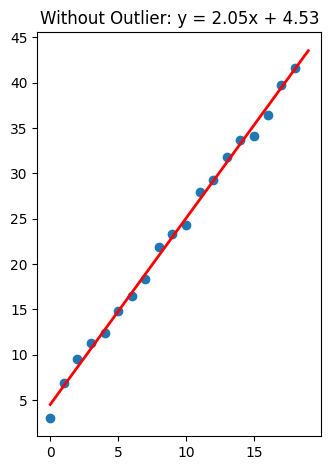

In [ ]:
# Plot without outlier
plt.subplot(1, 2, 2)
plt.scatter(x[:-1], y[:-1])
model = LinearRegression().fit(x[:-1], y[:-1])
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'Without Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

plt.tight_layout()
plt.show()

# Interactive Coding Exercise: Advanced Outlier Detection & Analysis


In [ ]:
# ----------------------------------------------------------------
# In this exercise, you'll work with a real-world dataset to:
# 1. Apply outlier detection techniques
# 2. Compare methods and their impact
# 3. Implement a custom outlier detection workflow

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the California housing dataset instead of Boston
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Create a DataFrame with all features plus the target
df = X.copy()
df['MedHouseVal'] = y  # The target is median house value

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFeature names:", list(X.columns))
print("\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


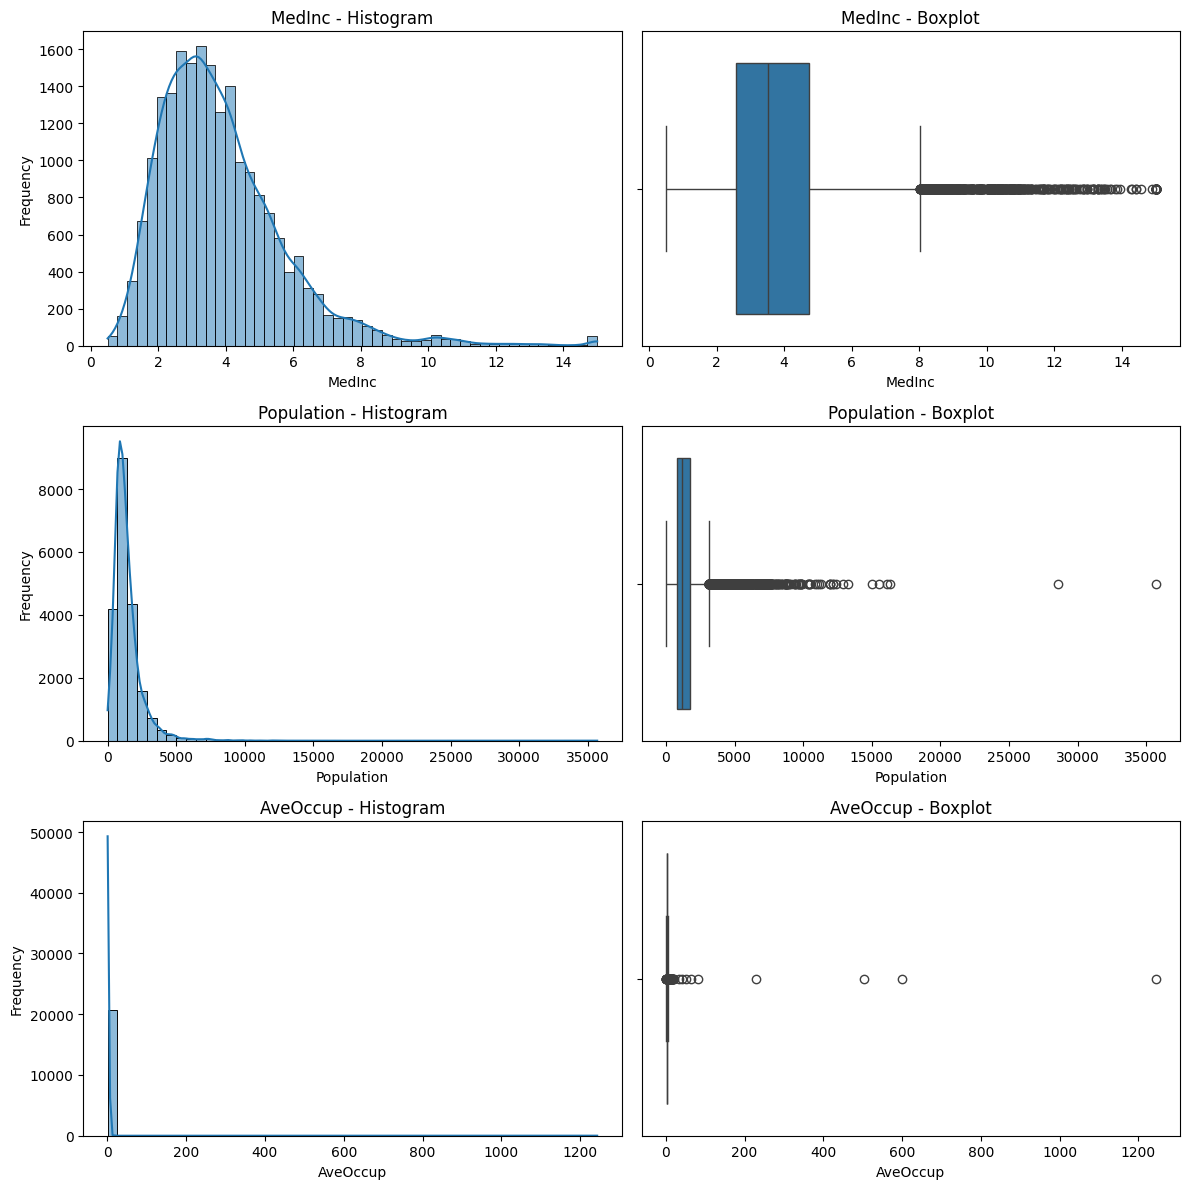

In [ ]:
# EXERCISE 1: Exploratory Data Analysis for Outlier Detection
# -----------------------------------------------------------
# TODO: Create histograms and boxplots for at least 3 features to visually identify outliers
features = ['MedInc', 'Population', 'AveOccup']

# Hint: Use subplot to organize multiple plots

# Your code here (replace this with your solution)
fig, axes = plt.subplots(3, 2, figsize=(12, 12))

for i, feature in enumerate(features):

    # Histogram
    sns.histplot(df[feature], bins=50, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{feature} - Histogram')
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel('Frequency')

    # Boxplot
    sns.boxplot(x=df[feature], ax=axes[i, 1])
    axes[i, 1].set_title(f'{feature} - Boxplot')
    axes[i, 1].set_xlabel(feature)
    plt.tight_layout()
plt.show()

In [ ]:
# EXERCISE 2: Implement Multiple Outlier Detection Methods
# -------------------------------------------------------

medhouseval = df['MedHouseVal']

# TODO: Implement both Z-score and IQR outlier detection for MedHouseVal feature

# Z-score method
z_scores = np.abs(zscore(medhouseval))
z_threshold = 3

z_outliers = df[z_scores > z_threshold]

print("Z-score Method")
print("Number of outliers:", len(z_outliers))
print(z_outliers[['MedHouseVal']])


# IQR method
Q1 = medhouseval.quantile(0.25)
Q3 = medhouseval.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df[(medhouseval < lower_bound) |
                  (medhouseval > upper_bound)]

print("IQR Method")
print("Number of outliers:", len(iqr_outliers))
print(iqr_outliers[['MedHouseVal']])

print("Comparison:")
print("Z-score outliers:", len(z_outliers))
print("IQR outliers:", len(iqr_outliers))

Z-score Method
Number of outliers: 0
Empty DataFrame
Columns: [MedHouseVal]
Index: []
IQR Method
Number of outliers: 1071
       MedHouseVal
89         5.00001
140        4.83300
459        5.00001
489        4.89600
493        5.00001
...            ...
20422      5.00001
20426      5.00001
20427      5.00001
20436      5.00001
20443      5.00001

[1071 rows x 1 columns]
Comparison:
Z-score outliers: 0
IQR outliers: 1071


In [ ]:
# EXERCISE 3: Advanced Outlier Detection - Isolation Forest
# --------------------------------------------------------
# TODO: Implement the Isolation Forest algorithm to detect outliers in the dataset
features = df.drop(columns=['MedHouseVal'])
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42
)
# Use contamination=0.05 (assuming 5% of data points are outliers)
# Return a binary mask where -1 represents outliers

# Your implementation here
outlier_labels = iso_forest.fit_predict(features)

outlier_mask = outlier_labels == -1

print("Isolation Forest Results")
print("-----------------------")
print("Total data points:", len(df))
print("Number of outliers:", sum(outlier_mask))

outliers = df[outlier_mask]

print("Outlier samples:")
print(outliers.head())

Isolation Forest Results
-----------------------
Total data points: 20640
Number of outliers: 1032
Outlier samples:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
59  2.5625       2.0  2.771930   0.754386        94.0  1.649123     37.82   
63  1.1910      52.0  7.698113   1.490566       521.0  3.276730     37.81   
73  0.4999      46.0  1.714286   0.571429        18.0  2.571429     37.81   
87  0.7600      10.0  2.651515   1.054545       546.0  1.654545     37.81   
89  1.2434      52.0  2.929412   0.917647       396.0  4.658824     37.80   

    Longitude  MedHouseVal  
59    -122.29      0.60000  
63    -122.30      0.76100  
73    -122.29      0.67500  
87    -122.27      1.62500  
89    -122.27      5.00001  


In [ ]:
# EXERCISE 4: Compare the Impact of Outliers on Linear Regression
# --------------------------------------------------------------
# TODO:
# 1. Create a simple linear regression model using 'Medlnc' to predict 'Medhouse'
X = df[['MedInc']]
y = df['MedHouseVal']

# 2. Create 3 versions:
#    a. With all data
model_all = LinearRegression()
model_all.fit(X, y)

y_pred_all = model_all.predict(X)

r2_all = r2_score(y, y_pred_all)
coef_all = model_all.coef_[0]

#    b. After removing Z-score outliers

z_scores = np.abs(zscore(df[['MedInc', 'MedHouseVal']]))

z_mask = (z_scores < 3).all(axis=1)

df_z = df[z_mask]

X_z = df_z[['MedInc']]
y_z = df_z['MedHouseVal']


model_z = LinearRegression()
model_z.fit(X_z, y_z)

y_pred_z = model_z.predict(X_z)

r2_z = r2_score(y_z, y_pred_z)
coef_z = model_z.coef_[0]

#    c. After removing Isolation Forest outliers
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso_labels = iso.fit_predict(df[['MedInc', 'MedHouseVal']])

iso_mask = iso_labels == 1
df_iso = df[iso_mask]

X_iso = df_iso[['MedInc']]
y_iso = df_iso['MedHouseVal']


model_iso = LinearRegression()
model_iso.fit(X_iso, y_iso)

y_pred_iso = model_iso.predict(X_iso)

r2_iso = r2_score(y_iso, y_pred_iso)
coef_iso = model_iso.coef_[0]


# 3. Compare the model performance metrics (r2_score) and coefficients
# Your implementation here

results = pd.DataFrame({
    'Method': [
        'All Data',
        'Without Z-score Outliers',
        'Without Isolation Forest Outliers'
    ],
    'R2 Score': [
        r2_all,
        r2_z,
        r2_iso
    ],
    'Coefficient': [
        coef_all,
        coef_z,
        coef_iso
    ]
})

print(results)


                              Method  R2 Score  Coefficient
0                           All Data  0.473447     0.417938
1           Without Z-score Outliers  0.432059     0.452109
2  Without Isolation Forest Outliers  0.455409     0.471190


In [ ]:
# EXERCISE 5: Create Your Own Outlier Detection Workflow
# -----------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore


# 1. Take dataframe and column name as input
def detect_consensus_outliers(data, column):

    x = data[column]

    # 2. Apply Z-score outlier detection
    z_scores = np.abs(zscore(x))
    z_outlier_indices = set(data.index[z_scores > 3])


    # Apply IQR outlier detection
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    iqr_outlier_indices = set(
        data.index[(x < lower_bound) | (x > upper_bound)]
    )


    # 3. Consensus outliers (detected by both methods)
    consensus_outliers = z_outlier_indices.intersection(
        iqr_outlier_indices
    )


    # 4. Visualization
    plt.figure(figsize=(10, 5))

    sns.boxplot(x=data[column])

    outlier_values = data.loc[list(consensus_outliers), column]

    plt.scatter(
        np.zeros(len(outlier_values)),
        outlier_values,
        color='red',
        label='Consensus Outliers',
        zorder=3
    )

    plt.title(f"Outlier Detection: {column}")
    plt.legend()
    plt.show()


    return consensus_outliers



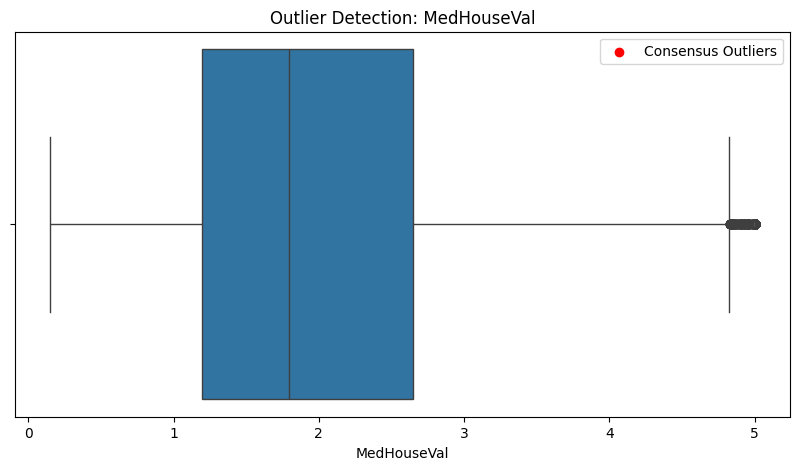

Consensus Outlier Indices:
set()
Number of Consensus Outliers: 0


In [ ]:
outliers = detect_consensus_outliers(df, 'MedHouseVal')

print("Consensus Outlier Indices:")
print(outliers)

print("Number of Consensus Outliers:", len(outliers))

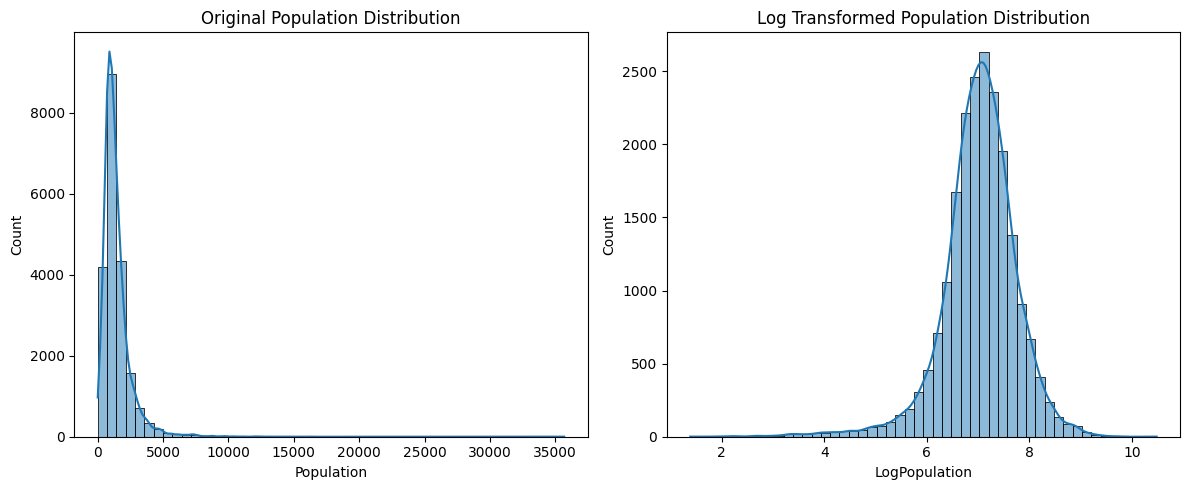

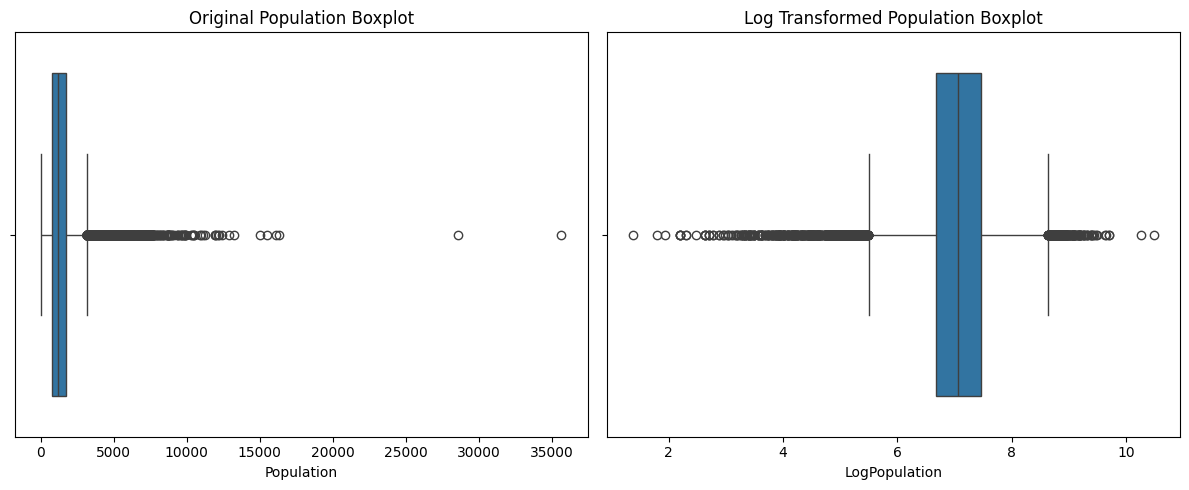

In [ ]:
# EXERCISE 6: Robust Feature Engineering with Outliers
# ---------------------------------------------------
# TODO: Create a new feature that is more robust to outliers
df['LogPopulation'] = np.log1p(df['Population'])
plt.figure(figsize=(12, 5))

# Suggestions:
# - Use log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['Population'], bins=50, kde=True)
plt.title("Original Population Distribution")
plt.xlabel("Population")
# - Use binning/discretization
# - Create a ratio or interaction feature
# Compare the distribution before and after your transformation
plt.subplot(1, 2, 2)
sns.histplot(df['LogPopulation'], bins=50, kde=True)
plt.title("Log Transformed Population Distribution")
plt.xlabel("LogPopulation")


plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['Population'])
plt.title("Original Population Boxplot")


plt.subplot(1, 2, 2)
sns.boxplot(x=df['LogPopulation'])
plt.title("Log Transformed Population Boxplot")


plt.tight_layout()
plt.show()

Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Mahalanobis Distance Results
-----------------------------------
Threshold: 3.548
Number of Outliers: 842

First Five Outliers
      MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
131  11.6017      18.0  8.335052   1.082474       533.0  2.747423     37.84   
155   8.8793      52.0  8.972868   1.131783       861.0  3.3372

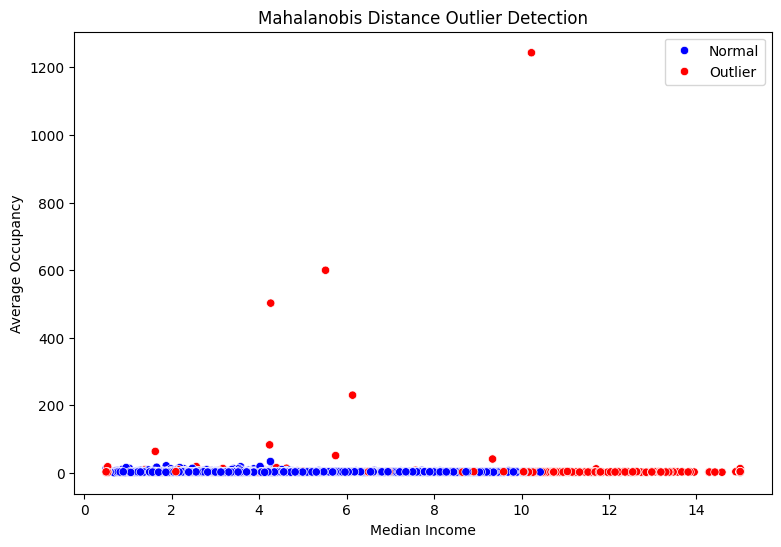

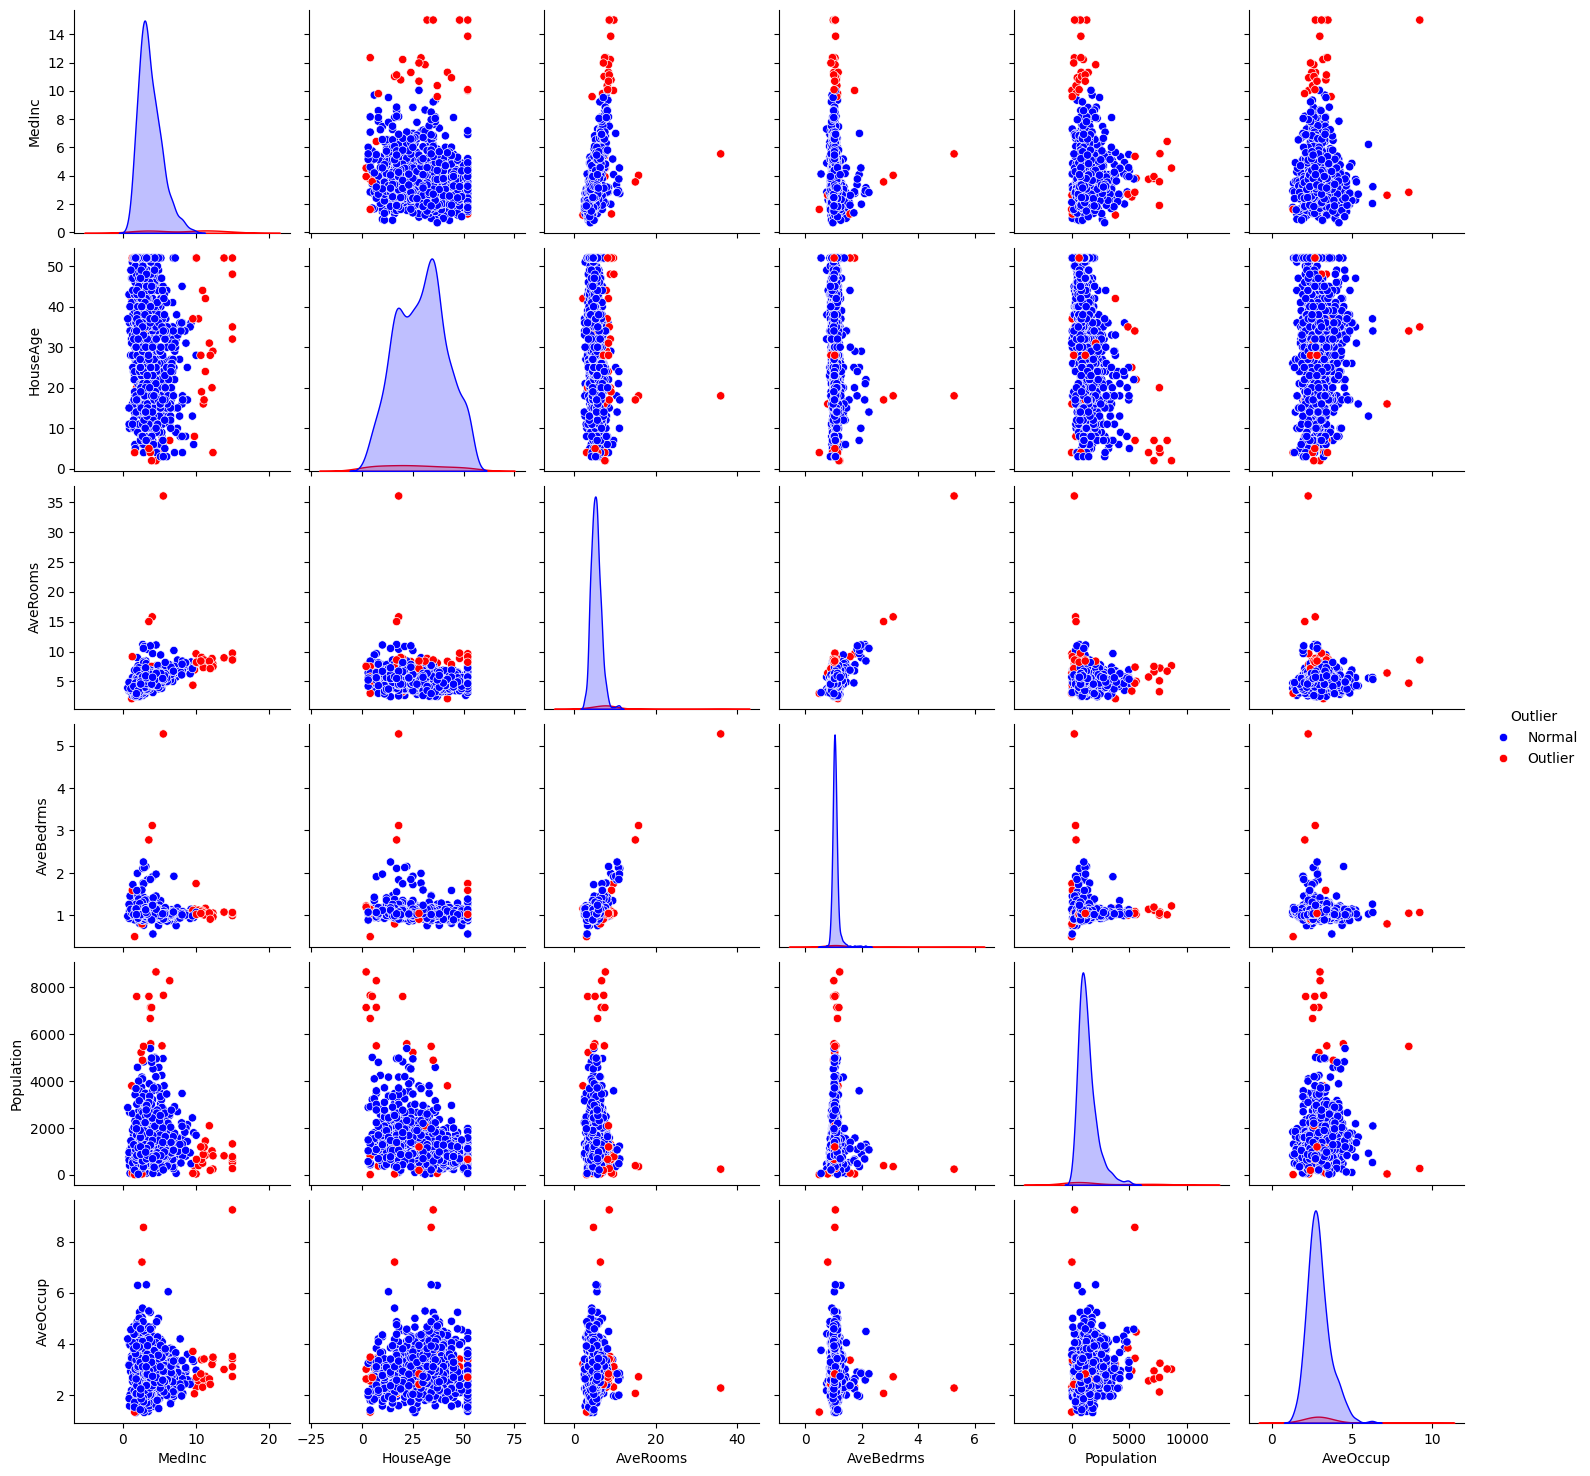

In [8]:
# ==========================================
# BONUS CHALLENGE: Multivariate Outlier Detection
# Using Mahalanobis Distance
# ==========================================

housing = fetch_california_housing(as_frame=True)
df = housing.frame

print("Dataset Shape:", df.shape)
print(df.head())

features = [
    'MedInc',
    'HouseAge',
    'AveRooms',
    'AveBedrms',
    'Population',
    'AveOccup'
]
X = df[features].dropna()

mean_vector = X.mean().values

cov_matrix = np.cov(X.values, rowvar=False)

cov_matrix_inv = np.linalg.pinv(cov_matrix)
mahalanobis_distances = []

for row in X.values:
    md = mahalanobis(row, mean_vector, cov_matrix_inv)
    mahalanobis_distances.append(md)
df.loc[X.index, "Mahalanobis_Distance"] = mahalanobis_distances

threshold = np.sqrt(chi2.ppf(0.95, df=len(features)))

df["Outlier"] = np.where(
    df["Mahalanobis_Distance"] > threshold,
    "Outlier",
    "Normal"
)

outliers = df[df["Outlier"] == "Outlier"]

print("Mahalanobis Distance Results")
print("-" * 35)
print(f"Threshold: {threshold:.3f}")
print(f"Number of Outliers: {len(outliers)}")

print("\nFirst Five Outliers")
print(outliers.head())

# Scatter Plot
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="MedInc",
    y="AveOccup",
    hue="Outlier",
    palette={
        "Normal": "blue",
        "Outlier": "red"
    }
)

plt.title("Mahalanobis Distance Outlier Detection")
plt.xlabel("Median Income")
plt.ylabel("Average Occupancy")

plt.legend(title="")
plt.show()

sample_df = df.sample(
    n=min(1000, len(df)),
    random_state=42
)
#Pair Plot
sns.pairplot(
    sample_df,
    vars=features,
    hue="Outlier",
    diag_kind="kde",
    palette={
        "Normal": "blue",
        "Outlier": "red"
    }
)

plt.show()